In [3]:
## IMPORTS AND SETUP
# Jupyter Notebook setup
%load_ext autoreload
%autoreload 2
import sys
sys.path.insert(0, "/tf/projet") # Add the project root directory to the Python path (docker hosting)

import tensorflow as tf
import os
from dotenv import load_dotenv
from Leyanda_Project.utils.warning_clean import silence_tensorflow_warnings
from Leyanda_Project.preprocessing.noise import load_clear_images, normalize_image, visualize_data, add_noise, create_denoising_model, train_denoising_model, plot_denoising_training_history, compare_denoised_images

# Suppress warnings
silence_tensorflow_warnings()

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"GPU is available: {len(gpus)} device(s) detected")
    except RuntimeError as e:
        print("Error configuring GPU:", str(e))
else:
    print("No GPU available, using CPU")

# Wandb setup
if not os.path.exists("/tf/projet/.env"):
    print("WARNING: No .env file found, please create one with your Wandb API key.")
    exit(1)
else:
    load_dotenv("/tf/projet/.env")
    WANDB_API_KEY = os.getenv("API_KEY")
    wandb_entity = "tom-antoine-cesi"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
TensorFlow warnings suppression is active.
GPU is available: 1 device(s) detected


In [4]:
## PARAMETERS
raw_data_path = "/tf/projet/Dataset_livrable_2" # Path to the raw data folder
img_height = 180 # Image height for dataset loading
img_width = 180 # Image width for dataset loading
batch_size = 16 # Batch size for dataset loading
save_model_denoise_filename = "denoiser.keras" # Model save filename
save_path = "/tf/projet/Leyanda_Project/models/saved" # Path to the models folder
n = 10 # Number of images displayed for visualization

# Dataset split parameters
train_split = 0.9 # Proportion of the dataset to use for training
test_split = 0.1 # Proportion of the dataset to use for testing

# Noise parameters
noise_factor = 0.2 # Percentage of noise added into the images
nb_epoch_denoise = 300 # Number of epochs ran by the denoising model

--Checking directory: /tf/projet/Dataset_livrable_2--
Directory /tf/projet/Dataset_livrable_2 exists

Loading images from /tf/projet/Dataset_livrable_2...

Normalizing images...


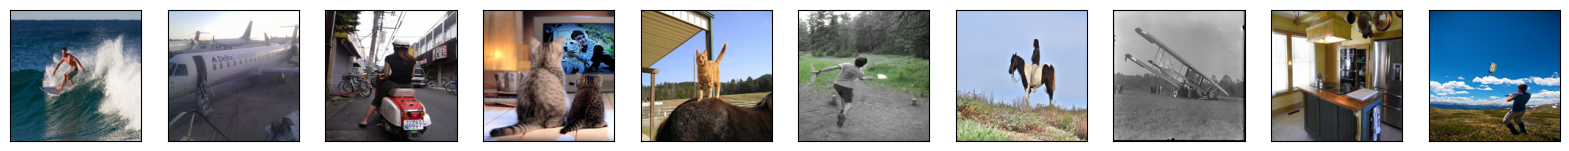

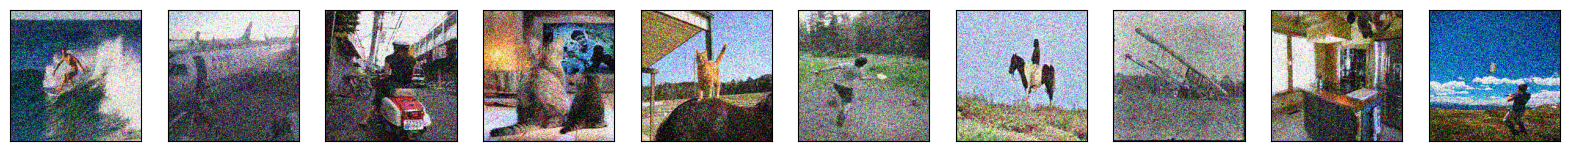

In [5]:
## DATA PREPARATION WORKFLOW
# 1. Check dataset existence
print(f"--Checking directory: {raw_data_path}--")
if not os.path.isdir(raw_data_path):
    print(f"Directory {raw_data_path} doesn't exist")
    exit(1)
else:
    print(f"Directory {raw_data_path} exists")

# 2. Load dataset
images_train, images_test = load_clear_images(
    raw_data_path=raw_data_path,
    img_height=img_height,
    img_width=img_width,
    test_split=test_split
)

# 3. Normalize dataset
x_train, x_test = normalize_image(images_train=images_train, images_test=images_test)

# 4. Visualize clear data
visualize_data(X=x_train, n=n)

# 5. Add noise to the dataset
x_train_noisy = add_noise(images=x_train, noise_factor=noise_factor)
x_test_noisy = add_noise(images=x_test, noise_factor=noise_factor)

# 6. Visualize noisy data
visualize_data(X=x_train_noisy, n=n)


Creating model...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 180, 180, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 180, 180, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 180, 180, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 180, 180, 32)   │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 180, 180, 16)   │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 180, 180, 3)    │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,035 (328.26 KB)

 Trainable params: 84,035 (328.26 KB)

 Non-trainable params: 0 (0.00 B)


Training denoising model...
Epoch 1/300
9/9 - 3s - 320ms/step - accuracy: 0.2892 - loss: 0.2446 - val_accuracy: 0.3786 - val_loss: 0.1185
Epoch 2/300
9/9 - 0s - 51ms/step - accuracy: 0.3727 - loss: 0.1173 - val_accuracy: 0.2746 - val_loss: 0.1141
Epoch 3/300
9/9 - 0s - 51ms/step - accuracy: 0.4257 - loss: 0.0971 - val_accuracy: 0.3834 - val_loss: 0.0975
Epoch 4/300
9/9 - 0s - 50ms/step - accuracy: 0.4321 - loss: 0.0872 - val_accuracy: 0.5502 - val_loss: 0.0850
Epoch 5/300
9/9 - 0s - 51ms/step - accuracy: 0.5577 - loss: 0.0736 - val_accuracy: 0.6068 - val_loss: 0.0735
Epoch 6/300
9/9 - 0s - 50ms/step - accuracy: 0.6036 - loss: 0.0668 - val_accuracy: 0.6441 - val_loss: 0.0643
Epoch 7/300
9/9 - 0s - 51ms/step - accuracy: 0.6301 - loss: 0.0610 - val_accuracy: 0.6364 - val_loss: 0.0595
Epoch 8/300
9/9 - 0s - 50ms/step - accuracy: 0.6376 - loss: 0.0571 - val_accuracy: 0.6614 - val_loss: 0.0596
Epoch 9/300
9/9 - 0s - 50ms/step - accuracy: 0.6390 - loss: 0.0555 - val_accuracy: 0.6764 - val_lo

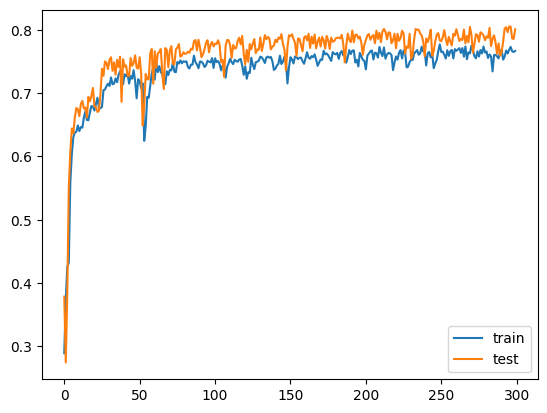

In [7]:
## MODEL WORKFLOW
# 1. Create model
model = create_denoising_model(img_height=img_height, img_width=img_width)

# 2. Train model
history = train_denoising_model(
    model=model,
    x_train_noisy=x_train_noisy,
    x_train=x_train,
    x_test_noisy=x_test_noisy,
    x_test=x_test,
    batch_size=batch_size,
    nb_epochs=nb_epoch_denoise
)

# 3. Plot training history
plot_denoising_training_history(history=history)

# 4. Save trained model
model_save_path = os.path.join(save_path, save_model_denoise_filename)
model.save(model_save_path)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step


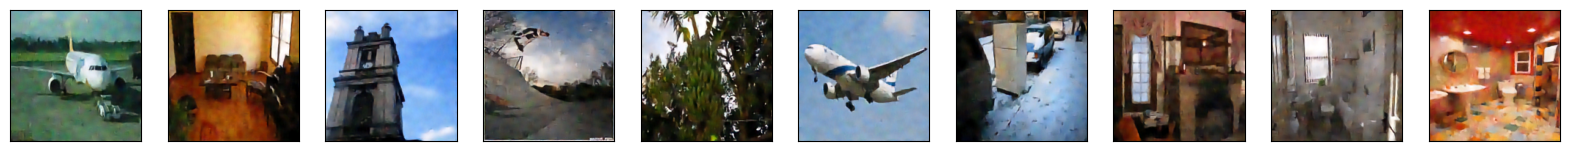

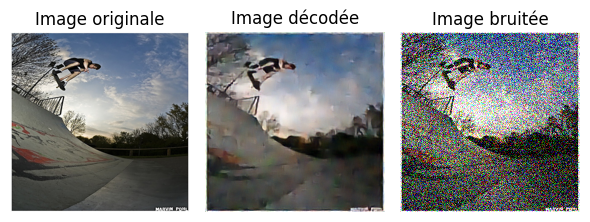

In [8]:
## EVALUATION AND INFERENCE
# 1. Make inference
decoded_imgs = model.predict(x_test_noisy)

# 2. Visualize
visualize_data(X=decoded_imgs, n=n)

# 3. Compare clear, noised and denoised images
compare_denoised_images(x_test=x_test, decoded_imgs=decoded_imgs, x_test_noisy=x_test_noisy)